In [1]:
import os
import sys

# Add the project's root directory to the Python path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import argparse
import random
import time
import os
import warnings
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
import copy
import torchvision
import warnings
import math


from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.optim.optimizer import Optimizer, required
from torch.optim.lr_scheduler import StepLR

%matplotlib inline

warnings.filterwarnings('ignore')

## Install R package BayesGPfit

from GP_comp.GP import gp_eigen_value, gp_eigen_funcs_fast, generate_grids

## 1. Model

### 1.1  BNNSTGP

In [2]:
## BNNSTGP Model
from utils import sample_inverse_gamma

class BNNSTGP_one_layer(nn.Module):
    def __init__(self, input_dim, n_hid, output_dim, w_dim, n_knots, phi1, phi2, eigenvalues, nu_tilde1 = 1., nu_tilde2 = 1., act='relu'):
        super(BNNSTGP_one_layer, self).__init__()

        self.input_dim = input_dim
        self.n_hid = n_hid
        self.output_dim = output_dim
        self.w_dim = w_dim
        self.n_knots = n_knots
        
        self.phi1 = phi1
        self.phi2 = phi2
        self.eigenvalues = torch.tensor(eigenvalues, dtype=torch.float32)
        
        values = torch.randn(n_hid, n_knots) * self.eigenvalues
        self.cu1 = nn.Parameter(values.T)
        self.TOTAL_ENTRIES_OF_CU1 = self.cu1.numel()

        values = torch.randn(n_hid, n_knots) * self.eigenvalues
        self.cu2 = nn.Parameter(values.T)
        self.TOTAL_ENTRIES_OF_CU2 = self.cu2.numel()       

        value = sample_inverse_gamma(2.0, 1.0, size=1).squeeze()
        self.sigma_theta_squared = nn.Parameter(torch.tensor(1.0), requires_grad=False)

        value = sample_inverse_gamma(2.0, 1.0, size=1).squeeze()
        self.sigma_lambda_squared1 = nn.Parameter(torch.tensor(1.0), requires_grad=False)

        value = sample_inverse_gamma(2.0, 1.0, size=1).squeeze()
        self.sigma_lambda_squared2 = nn.Parameter(torch.tensor(1.0), requires_grad=False)

        self.nu_tilde1 = nu_tilde1
        self.nu_tilde2 = nu_tilde2
        
        value = sample_inverse_gamma(2.0, 1.0, size=1).squeeze()
        self.sigma_squared = nn.Parameter(torch.tensor(1.0), requires_grad=False)
        
        self.fully_connected_nn = nn.Parameter(torch.Tensor(n_hid, output_dim).normal_(0, math.sqrt(self.sigma_theta_squared)))
        self.ksi = nn.Parameter(torch.Tensor(n_hid).normal_(0, math.sqrt(self.sigma_theta_squared)))
        self.NUM_PARAMS = self.count_num_params()
        
        if act == 'relu':
            self.act = torch.relu
        elif act == 'tanh':
            self.act = torch.tanh
        elif act == 'sigmoid':
            self.act = torch.sigmoid
        else:
            raise ValueError('Invalid activation function %s' % act)

    def forward(self, x1, x2, w):
        out1 = torch.mm(self.phi1, self.cu1)
        out1 = F.threshold(out1, self.nu_tilde1, self.nu_tilde1) - F.threshold(-out1, self.nu_tilde1, self.nu_tilde1)
        out1 = math.sqrt(self.sigma_lambda_squared1) * out1
        
        out2 = torch.mm(self.phi2, self.cu2)
        out2 = F.threshold(out2, self.nu_tilde2, self.nu_tilde2) - F.threshold(-out2, self.nu_tilde2, self.nu_tilde2)
        out2 = math.sqrt(self.sigma_lambda_squared2) * out2
        
        out = torch.mm(x1, out1) + torch.mm(x2, out2) + self.ksi

        out = self.act(out)
        out = torch.mm(out, self.fully_connected_nn)

        return out

    def log_prior(self):
        logprior = 0.5 * (self.cu1 ** 2).sum() / self.sigma_lambda_squared1
        logprior += 0.5 * (self.cu2 ** 2).sum() / self.sigma_lambda_squared2
        logprior += 0.5 * (self.fully_connected_nn ** 2).sum() / self.sigma_theta_squared
        logprior += 0.5 * (self.ksi ** 2).sum() / self.sigma_theta_squared
        return logprior

    def count_num_params(self):
        count = 0
        for name, parameter in self.named_parameters():
            if (name == 'fully_connected_nn' or name == 'ksi'):
                count += parameter.numel()
        return count
        
    def sample_and_set_sigma_squared(self, n, loss, a=1000, b=1.0):
        with torch.no_grad():
            new_a = a + n / 2.0
            new_b = b + loss / 2.0
            sigma_squared = sample_inverse_gamma(new_a, new_b, size=1).squeeze()
            self.sigma_squared.copy_(sigma_squared)
            return self.sigma_squared

    def sample_and_set_sigma_lambda_squared(self, a_lambda1=2.0, b_lambda1=1.0, a_lambda2=2.0, b_lambda2=1.0):
        with torch.no_grad():
            new_a_lambda1 = a_lambda1 + self.TOTAL_ENTRIES_OF_CU1 / 2.0
            new_b_lambda1 = b_lambda1 + torch.sum(self.cu1 ** 2) / 2.0
            sigma_lambda_squared1 = sample_inverse_gamma(new_a_lambda1, new_b_lambda1, size=1).squeeze()
            self.sigma_lambda_squared1.copy_(sigma_lambda_squared1)
            
            new_a_lambda2 = a_lambda2 + self.TOTAL_ENTRIES_OF_CU2 / 2.0
            new_b_lambda2 = b_lambda2 + torch.sum(self.cu2 ** 2) / 2.0
            sigma_lambda_squared2 = sample_inverse_gamma(new_a_lambda2, new_b_lambda2, size=1).squeeze()
            self.sigma_lambda_squared2.copy_(sigma_lambda_squared2)
            
            return self.sigma_lambda_squared1, self.sigma_lambda_squared2

    def sample_and_set_sigma_theta_squared(self, a_theta=2.0, b_theta=1.0):
        """
        Sample σβ^2 from an Inverse-Gamma distribution using equation (21), with data dependency via β^T β.
        Returns:
            torch.Tensor: Sampled σβ^2 from the Inverse-Gamma distribution.
        """
        with torch.no_grad():
            new_a_theta = a_theta + self.NUM_PARAMS / 2.0
            new_b_theta = b_theta + torch.sum(self.fully_connected_nn ** 2) / 2.0 + torch.sum(self.ksi ** 2) / 2.0

            sigma_theta_squared = sample_inverse_gamma(new_a_theta, new_b_theta, size=1).squeeze()
            self.sigma_theta_squared.copy_(sigma_theta_squared)
            return self.sigma_theta_squared



### 1.2 SGLD 

In [3]:
## SGLD (Stochastic Gradient Langevin Dynamics)

class SGLD(Optimizer):
    def __init__(self, params, lr = required, langevin = True):
        self.langevin = langevin
        defaults = dict(lr=lr)
        super(SGLD, self).__init__(params, defaults)

    @torch.no_grad()
    def step(self):
        loss = None
        
        for group in self.param_groups:
            
            for p in group['params']:
                if p.grad is None:
                    continue
                d_p = p.grad
                
                if self.langevin == True:
                    langevin_noise = p.new(p.size()).normal_(mean=0, std=1)/np.sqrt(group['lr'])
                    p.add_(0.5*d_p + langevin_noise, alpha = -group['lr'])

                else:
                    p.add_(0.5*d_p, alpha = -group['lr'])


        return loss


### 1.3 Network Wrapper

In [4]:

## Network Wrapper

class Net(object):

    def __init__(self, task='binary', lr=1e-3, input_dim=784, n_hid = 128, output_dim = 1, w_dim = 1, n_knots = 66,
                 N_train=200, phi1=None, phi2 = None, eigenvalues=None, nu_tilde1 = 1, nu_tilde2 = 1, langevin = True, step_decay_epoch = 100, step_gamma = 0.1, act = 'relu'):
        
        #print(' Creating Net!! ')
        self.task = task
        if task not in ['binary', 'multiclass', 'regression']:
            raise ValueError('Invalid task %s' % task)
        self.lr = lr

        self.input_dim = input_dim
        self.n_hid = n_hid
        self.output_dim = output_dim
        self.w_dim = w_dim
        
        self.n_knots = n_knots
        self.phi1 = phi1
        self.phi2 = phi2
        self.eigenvalues = eigenvalues
        self.nu_tilde1 = nu_tilde1
        self.nu_tilde2 = nu_tilde2
        self.act = act

        self.N_train = N_train
        self.langevin = langevin
        self.step_decay_epoch = step_decay_epoch
        self.step_gamma = step_gamma

        self.create_net()
        self.create_opt()
        self.epoch = 0
        
        self.weight_set_samples = []
        self.r2_train = []
        self.r2_test = []

    def create_net(self):
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.model = BNNSTGP_one_layer(input_dim=self.input_dim, n_hid=self.n_hid, output_dim=self.output_dim, 
                            w_dim=self.w_dim, n_knots = self.n_knots, phi1=torch.tensor(self.phi1).to(self.device),
                            phi2=torch.tensor(self.phi2).to(self.device), eigenvalues=self.eigenvalues,
                            nu_tilde1 = self.nu_tilde1, nu_tilde2 = self.nu_tilde2, act = self.act)
        self.model.to(self.device)


    def create_opt(self):
        self.optimizer = SGLD(params=self.model.parameters(), lr=self.lr, langevin = self.langevin)
        self.scheduler = StepLR(self.optimizer, step_size = self.step_decay_epoch, gamma=self.step_gamma)


    def fit(self, x1, x2, w, y, threshold=0.5):
        x1 = x1.to(self.device)
        x2 = x2.to(self.device)
        w = w.to(self.device)

        if self.task == 'binary':
            y = y.float().to(self.device).reshape(-1, 1)
            self.optimizer.zero_grad()

            out = self.model(x1, x2, w)
            loss = F.binary_cross_entropy_with_logits(out, y, reduction='mean')
            loss = loss * self.N_train 
            #loss += self.model.log_prior()
            
            loss.backward()
            self.optimizer.step() 

            pred = (torch.sigmoid(out)>threshold).long()
            accu = (pred == y.long()).sum().float()
        elif self.task == 'regression':
            y = y.float().to(self.device).reshape(-1, 1)
            self.optimizer.zero_grad()

            out = self.model(x1, x2, w)
            mse_loss = F.mse_loss(out, y, reduction='mean')
            self.r2_train.append(1 - mse_loss.detach().item() / torch.var(y).item())
            adjusted_loss = mse_loss * self.N_train / self.model.sigma_squared / 2.0
            total_loss = adjusted_loss + self.model.log_prior()
            
            total_loss.backward()
            self.optimizer.step() 

            pred = 0.0
            accu = 0.0
            return mse_loss, accu 

        else:                           ## multiclass
            y = y.long().to(self.device).reshape(-1)
            self.optimizer.zero_grad()

            out = self.model(x, w)
            loss = F.cross_entropy(out, y, reduction = 'mean')
            loss = loss * self.N_train

            loss += self.model.log_prior()
            
            loss.backward()
            self.optimizer.step()

            pred = out.max(dim=1, keepdim=False)[1]
            accu = (pred == y).sum()

        return loss*x.shape[0]/self.N_train, accu
    

    def get_nb_parameters(self):
        return sum(p.numel() for p in self.model.parameters())


    def save_net_weights(self, max_samples):
        
        if len(self.weight_set_samples) >= max_samples:
            self.weight_set_samples.pop(0)
            
        self.weight_set_samples.append(copy.deepcopy(self.model.state_dict()))
        #print(' saving weight samples %d/%d' % (len(self.weight_set_samples), max_samples) )


    def all_sample_eval(self, x1, x2, w, y, threshold=0.5):    
        x1 = x1.to(self.device)
        x2 = x2.to(self.device)
        w = w.to(self.device)
        y = y.float().to(self.device)
        
        pred = x1.new(len(self.weight_set_samples), x1.shape[0], self.output_dim) + x2.new(len(self.weight_set_samples), x2.shape[0], self.output_dim)
        
        for i, weight_dict in enumerate(self.weight_set_samples):
            self.model.load_state_dict(weight_dict)
            out_i = self.model(x, w)
            pred[i] = torch.sigmoid(out_i)
            
        pred = (pred.mean(0)>threshold).float()
        accu = (pred == y).sum().float()

        return accu


    def save(self, filename):
        print('Writting %s\n' % filename)
        torch.save({
            'epoch': self.epoch,
            'lr': self.lr,
            'model': self.model,
            'optimizer': self.optimizer,
            'scheduler': self.scheduler}, filename)

    def load(self, filename):
        print('Reading %s\n' % filename)
        state_dict = torch.load(filename)
        self.epoch = state_dict['epoch']
        self.lr = state_dict['lr']
        self.model = state_dict['model']
        self.optimizer = state_dict['optimizer']
        self.scheduler = state_dict['scheduler']
        print('  restoring epoch: %d, lr: %f' % (self.epoch, self.lr))
        return self.epoch


## 2. Load sythntic Data by Guoxuan

Simulated 1000 images of 100×100 = 10000 pixels


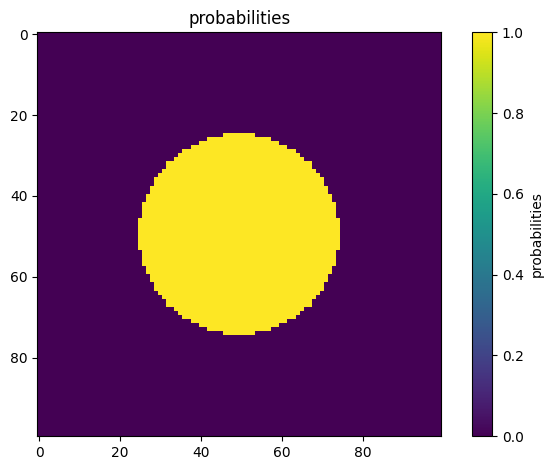

Simulated 1000 images of 200×200 = 40000 pixels


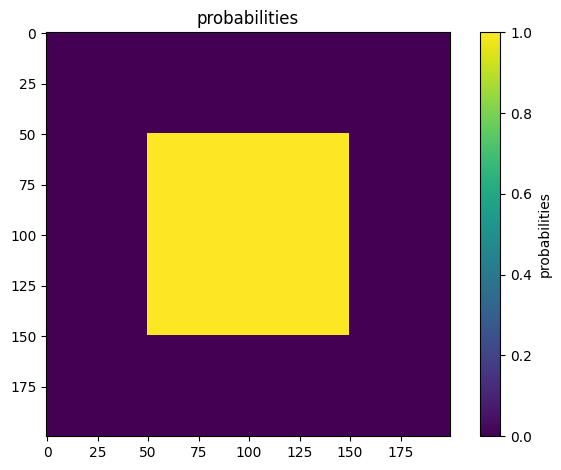

In [5]:
from simulate_data import simulate_data_circle_square
from utils import generate_linear_data, plot_mse, plot_sigma_squared, plot_image
from torch.utils.data import Dataset, DataLoader
import torch
from torch.utils.data import Dataset
# Step 2: Generate synthetic data
# simulate a batch of images
in_feature1 = 100
in_feature2 = 200
r2 = 0.5                  # signal-to-noise ratio
n = 1000                  # number of images/samples
v_list1, v_list2, true_beta1, true_beta2, img1, img2, Y = simulate_data_circle_square(n=n, r2=r2, dim1=in_feature1, dim2=in_feature2, random_seed=42)
# torch tensors

# pick one of your simulated images
print(f"Simulated {n} images of {in_feature1}×{in_feature1} = {img1.shape[1]} pixels")
plot_image(true_beta1)
print(f"Simulated {n} images of {in_feature2}×{in_feature2} = {img2.shape[1]} pixels")

plot_image(true_beta2)
X1 = torch.from_numpy(img1).float().to('cpu')    # X.shape= (number of rows, total number of vexels)
X2 = torch.from_numpy(img2).float().to('cpu') 
y = torch.from_numpy(Y).float().to('cpu')      # y.shape= (number of rows,)

#y = scale_data(y, torch.mean(y), torch.std(y))

class mydata(Dataset):
    def __init__(self, x1_list, x2_list, y_list):
        self.x1_list = x1_list
        self.x2_list = x2_list
        self.y_list = y_list
    def __len__(self):
        return len(self.y_list)
    def __getitem__(self, i):
        x1 = self.x1_list[i].reshape(-1)
        x2 = self.x2_list[i].reshape(-1)
        w = torch.tensor([1.])
        y = torch.tensor([self.y_list[i]])
        return (x1, x2, w), y

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split, TensorDataset

def create_dataloaders(X1, X2, y, val_ratio=0.2, batch_size=32, shuffle=True):
    """
    Splits X, y into training and validation DataLoaders.
    
    Args:
        X (torch.Tensor): Feature tensor, shape (n_samples, n_features).
        y (torch.Tensor): Target tensor, shape (n_samples,).
        val_ratio (float): Proportion of dataset to use for validation (default=0.2).
        batch_size (int): Batch size for DataLoader (default=32).
        shuffle (bool): Whether to shuffle the dataset before splitting (default=True).
    
    Returns:
        train_loader (DataLoader), val_loader (DataLoader)
    """
    # Wrap tensors into a TensorDataset
    dataset = mydata(X1, X2, y)
    
    # Calculate sizes
    n_samples = len(dataset)
    n_val = int(n_samples * val_ratio)
    n_train = n_samples - n_val
    
    # Random split
    train_dataset, val_dataset = random_split(dataset, [n_train, n_val])
    # train_y_mean = train_dataset.y.mean()
    # train_y_std = train_dataset.y.std()

    # #scaling the data
    # train_dataset.y = scale_data(train_dataset, train_y_mean, train_y_std)
    # val_dataset.y = scale_data(val_dataset, train_y_mean, train_y_std)
    
    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=shuffle)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, n_train, n_val
train_loader, val_loader, n_train, n_test = create_dataloaders(X1, X2, y, val_ratio=0.2, batch_size=64)
train_loader_all, _, _, _ = create_dataloaders(X1, X2, y, val_ratio=0.2, batch_size=n_train)


## 3. Training using full data

In [7]:
class MNIST_runner:
    def __init__(self, train_loader, val_loader, lr = 5e-7, a_for_eigen=0.0001, b_for_eigen = 20, nu_tilde1 = 2.5, nu_tilde2 = 2.5, langevin = True, seed = 17, act = 'relu'):
        self.train_loader = train_loader
        self.val_loader = val_loader
        
        self.lr = lr
        self.b_for_eigen = b_for_eigen
        self.nu_tilde1 = nu_tilde1
        self.nu_tilde2 = nu_tilde2
        self.langevin = langevin
        self.seed = seed
        self.act = act
        self.curr_epoch = 0
        self.total_epochs = 0
        
        self.start_save = 0
        self.save_every = 2
        self.N_saves = 100
        self.test_every = 5
        self.print_every = 10
        
        self.loss_train = []
        self.accu_train = []
        self.loss_val = []
        self.accu_val = []

        grids1 = generate_grids(dimensions=2, num_grids=in_feature1)
        phi1 = gp_eigen_funcs_fast(grids1, poly_degree=30, a=a_for_eigen, b=b_for_eigen)
        phi1 = np.array(phi1)
        
        grids2 = generate_grids(dimensions=2, num_grids=in_feature2)
        phi2 = gp_eigen_funcs_fast(grids2, poly_degree=30, a=a_for_eigen, b=b_for_eigen)
        phi2 = np.array(phi2)
        
        eigenvalues_np = gp_eigen_value(poly_degree=30, a=a_for_eigen, b=b_for_eigen)
        #phi = phi * np.sqrt(eigenvalues_np)
        torch.set_default_dtype(torch.float32)

        self.net = Net(lr=lr, input_dim=in_feature1*in_feature1, n_hid = 64, output_dim = 1, w_dim = 1, n_knots = phi1.shape[1],
            N_train=len(train_loader.dataset.indices), phi1=torch.tensor(phi1, dtype=torch.float32), phi2=torch.tensor(phi2, dtype=torch.float32), 
            eigenvalues=eigenvalues_np, nu_tilde1 = nu_tilde1, nu_tilde2 = nu_tilde2, langevin=langevin,
            step_decay_epoch = 1000, step_gamma = 0.1, act = act, task='regression')
        
    def train(self, n_epochs):
        self.total_epochs += n_epochs
        for i in range(self.curr_epoch, self.total_epochs):
            tic = time.time()
            self.net.scheduler.step()
            
            for (x1, x2, w), y in self.train_loader:
                mse_loss, accu = self.net.fit(x1, x2, w, y)
                self.net.model.sample_and_set_sigma_lambda_squared()
                self.net.model.sample_and_set_sigma_theta_squared()
                #self.net.model.sample_and_set_sigma_squared(len(train_loader.dataset), mse_loss)
                
            with torch.no_grad():
                X1_train = self.train_loader.dataset.dataset.x1_list[self.train_loader.dataset.indices, :]
                X2_train = self.train_loader.dataset.dataset.x2_list[self.train_loader.dataset.indices, :]
                y_train = self.train_loader.dataset.dataset.y_list[self.train_loader.dataset.indices]
                pred = self.net.model(X1_train, X2_train, 1).to("cpu").detach().numpy()
                sse = np.sum((y_train.numpy() - pred.reshape(-1)) ** 2)
                self.net.model.sample_and_set_sigma_squared(len(train_loader.dataset), sse)
                self.loss_train.append(sse.item() / (X1_train.shape[0]))
                self.accu_train.append(accu)
                
            toc = time.time()
    
            if i > self.start_save and i % self.save_every == 0:
                self.net.save_net_weights(max_samples = self.N_saves)
    
            if i % self.test_every == 0:
                with torch.no_grad():
                    tic = time.time()
                    X1_val = self.val_loader.dataset.dataset.x1_list[self.val_loader.dataset.indices, :]
                    X2_val = self.val_loader.dataset.dataset.x2_list[self.val_loader.dataset.indices, :]
                    y_val = self.val_loader.dataset.dataset.y_list[self.val_loader.dataset.indices]
                    pred = self.net.model(X1_val, X2_val, 1).to("cpu").detach().numpy()
                    sse = np.sum((y_val.numpy() - pred.reshape(-1)) ** 2)
                    mse = sse.item() / (X1_val.shape[0])
                    self.net.r2_test.append(1 - mse / torch.var(y_val).item())
                    self.loss_val.append(mse)
                    self.accu_val.append(accu)
    
                    toc = time.time()

            if i % self.print_every == 0:
                print('Epoch %d, train accuracy %.2f%%, loss_train=%s' % (i, self.accu_train[-1]*100, self.loss_train[-1]))
                print('Epoch %d, test accuracy %.2f%%, loss_val=%s' % (i, self.accu_val[-1]*100, self.loss_val[-1]))
        self.curr_epoch += n_epochs

In [8]:
def calculate_beta(trainer, burnin = 0.5):
    betas1= []
    betas2=[]
    for j, weight_dict in enumerate(trainer.net.weight_set_samples):
        if j > len(trainer.net.weight_set_samples) * burnin:
            trainer.net.model.load_state_dict(weight_dict)
            tmp = torch.mm(trainer.net.model.phi1, trainer.net.model.cu1)
            tmp = F.threshold(tmp, trainer.net.model.nu_tilde1, trainer.net.model.nu_tilde1) - F.threshold(-tmp, trainer.net.model.nu_tilde1, trainer.net.model.nu_tilde1)
            tmp = math.sqrt(trainer.net.model.sigma_lambda_squared1) * tmp
            beta1 = tmp.cpu().detach().numpy()
            betas1.append(beta1)

            tmp = torch.mm(trainer.net.model.phi2, trainer.net.model.cu2)
            tmp = F.threshold(tmp, trainer.net.model.nu_tilde1, trainer.net.model.nu_tilde1) - F.threshold(-tmp, trainer.net.model.nu_tilde1, trainer.net.model.nu_tilde1)
            tmp = math.sqrt(trainer.net.model.sigma_lambda_squared1) * tmp
            beta2 = tmp.cpu().detach().numpy()
            betas2.append(beta2)
    beta_arr1 = np.stack(betas1, axis=0)
    beta_arr2 = np.stack(betas2, axis=0)
    return beta_arr1, beta_arr2

def calculate_mask(beta, threshold=0.003, gamma=0.5):
    thresholded_mask = abs(beta) > threshold
    any_nz = np.any(thresholded_mask, axis = 2).astype(int)
    p_hat = any_nz.astype(float).mean(axis = 0)
    order = np.argsort(-p_hat)
    p_sorted = p_hat[order]
    fdr = np.cumsum(1 - p_sorted) / np.arange(1, len(p_sorted) + 1)
    valid = np.where(fdr <= gamma)[0]
    if valid.size > 0:
        r = int(valid[-1] + 1)
        delta = float(p_sorted[r - 1])
    else:
        r, delta = 0, 1.0
    mask = p_hat >= delta
    return mask, p_hat

In [9]:
trainer = MNIST_runner(train_loader, val_loader, lr = 1e-6, a_for_eigen = 0.0001, b_for_eigen = 2000, nu_tilde1 = 0.1, nu_tilde2 = 0.1, act = "relu")
trainer.train(200)

Epoch 0, train accuracy 0.00%, loss_train=21.510380859375
Epoch 0, test accuracy 0.00%, loss_val=23.258349609375
Epoch 10, train accuracy 0.00%, loss_train=1.5632998657226562
Epoch 10, test accuracy 0.00%, loss_val=1.7860012817382813
Epoch 20, train accuracy 0.00%, loss_train=0.9741866302490234
Epoch 20, test accuracy 0.00%, loss_val=0.8880386352539062
Epoch 30, train accuracy 0.00%, loss_train=0.9643385314941406
Epoch 30, test accuracy 0.00%, loss_val=0.8808074951171875
Epoch 40, train accuracy 0.00%, loss_train=0.9554087066650391
Epoch 40, test accuracy 0.00%, loss_val=0.88596435546875
Epoch 50, train accuracy 0.00%, loss_train=0.8903816986083984
Epoch 50, test accuracy 0.00%, loss_val=0.8174646759033203
Epoch 60, train accuracy 0.00%, loss_train=0.7593614959716797
Epoch 60, test accuracy 0.00%, loss_val=0.7282158660888672
Epoch 70, train accuracy 0.00%, loss_train=0.6590245056152344
Epoch 70, test accuracy 0.00%, loss_val=0.6752765655517579
Epoch 80, train accuracy 0.00%, loss_train

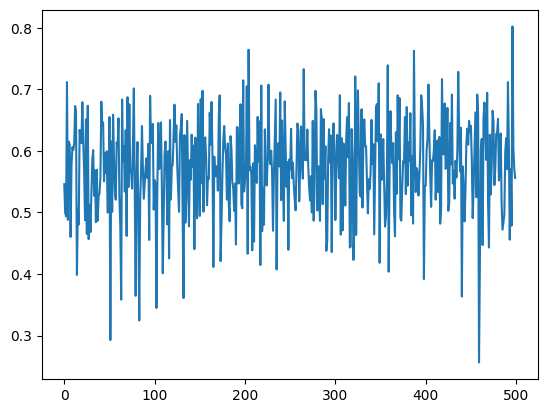

In [10]:
plt.plot(trainer.net.r2_train[-500:]);

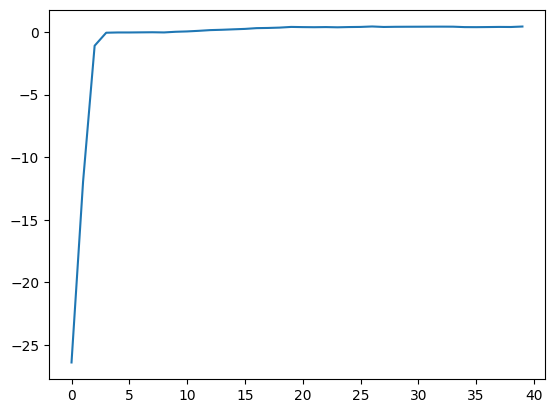

In [11]:
plt.plot(trainer.net.r2_test[-50:]);

In [12]:
from sklearn.metrics import confusion_matrix

In [42]:
beta1, beta2 = calculate_beta(trainer, 0.5)
mask1, p_hat1 = calculate_mask(beta1, threshold=0.0013, gamma=0.1)
mask2, p_hat2 = calculate_mask(beta2, threshold=0.0013, gamma=0.1)

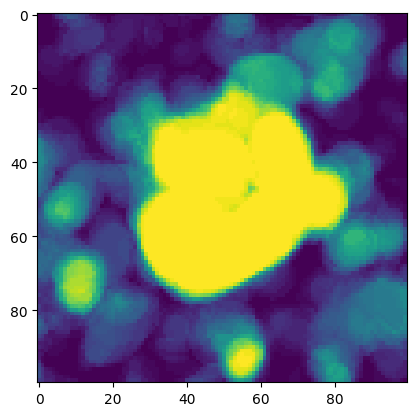

In [43]:
plt.imshow(np.array(p_hat1).reshape((in_feature1, in_feature1)));

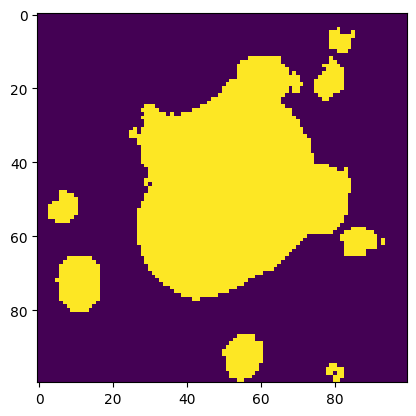

In [44]:
plt.imshow(np.array(mask1).reshape((in_feature1, in_feature1)));

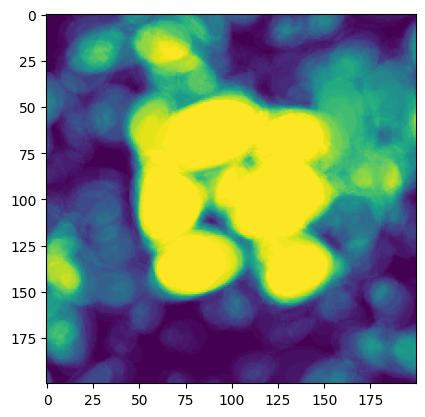

In [45]:
plt.imshow(np.array(p_hat2).reshape((in_feature2, in_feature2)));

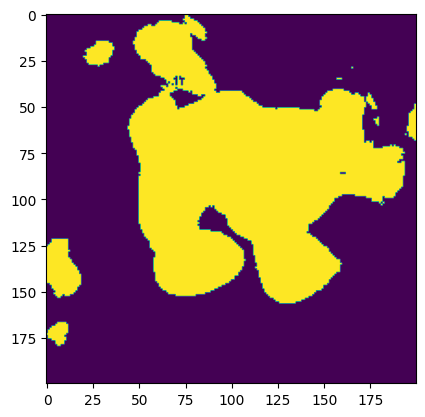

In [46]:
plt.imshow(np.array(mask2).reshape((in_feature2, in_feature2)));

In [47]:
confusion_matrix(true_beta1, mask1)

array([[6952, 1120],
       [  72, 1856]], dtype=int64)

In [48]:
confusion_matrix(true_beta2, mask2)

array([[25450,  4550],
       [  885,  9115]], dtype=int64)

In [49]:
sigsq_list = []
for i in trainer.net.weight_set_samples:
    sigsq_list.append(i["sigma_squared"])

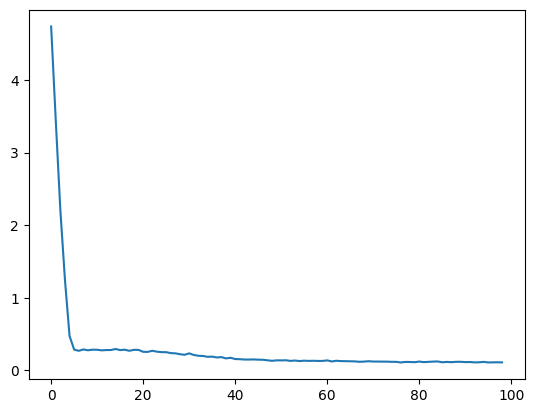

In [50]:
plt.plot(np.array(sigsq_list));